# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [3]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=84cf9c73-36d3-4622-a975-27824edfbdcb
To: c:\Users\IanEz\OneDrive\Documentos\GitHub\Aprendizaje-Profundo\Practica\TP_N3\archivo.zip
100%|██████████| 40.0M/40.0M [00:03<00:00, 10.9MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



<p>Se revisa la documentación provista sobre "torchvision.transforms". De la revisión de la misma, se concluye que será útil el modulo "functional" ya que permiten mayor control sobre las transformaciones a aplicar.</p>
<p><b>Transformaciones:</b><br>Para determinar qué transformaciones necesitamos, primero deberemos explorar nuestro dataset:</p>

In [ ]:
import PIL 
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np

In [117]:
#Genero un diccionario para mapear los labels
label_dict = {
       '0':        'alegria' ,
       '1':        'disgusto',
       '2':        'enojo',
       '3':        'miedo',
       '4':        'seriedad',
       '5':        'sorpresa',
       '6':        'tristeza'
}
#Genero una función para poder obtener un label categórico en base al diccionario definido
def getLabel(label):
    return (dict[str(label.item())])

In [118]:
#Defino ruta donde se encuentran almacenadas las imagenes
train_data_path = r'.\datos_zip\dataset_emociones\train'
test_data_path = r'.\datos_zip\dataset_emociones\validation'

In [ ]:
import pandas as pd
from pathlib import Path
import imagesize

# 1. Get the Image Resolutions using recursive globbing
# rglob("*.jpg") will automatically dig into /happiness/, /fear/, etc.
path = Path(train_data_path)
img_meta = {}

for img_path in path.rglob("*.jpg"):
    # imagesize.get() safely accepts pathlib Path objects directly, 
    # saving us from string concatenation errors!
    img_meta[img_path.name] = imagesize.get(img_path)

# 2. Build a structured list for Pandas
# This prevents the ValueError by ensuring exactly 3 columns are created per row
data_rows = []
for filename, size in img_meta.items():
    data_rows.append({
        "FileName": filename,
        "Width": size[0],
        "Height": size[1]
    })

# 3. Convert directly to DataFrame
img_meta_df = pd.DataFrame(data_rows)

# 4. Compute Aspect Ratio (Protected by an empty check)
if not img_meta_df.empty:
    img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)
    
    print(f'Total Nr of Images in the dataset: {len(img_meta_df)}')
    print(f'Valores únicos de "Widht" {img_meta_df['Width'].unique()}')
    print(f'Valores únicos de "Height" {img_meta_df['Height'].unique()}')
else:
    print("No se encontraron imagenes en 'trian_data_path'")

Total Nr of Images in the dataset: 12271
Valores únicos de "Widht" [100]
Valores únicos de "Height" [100]


<p>Se comprueba que todas las imágenes poseen el mismo tamaño, con lo cuál, no será necesario aplicar un Resize

In [ ]:

#TODO: Definir transformaciones
transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.RandomEqualize(p=1.0), #ecualizamos el histograma de las imagenes para lograr mayor constraste y detalle en las mismas (p=1 => se aplica el 100% de las veces)     
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5

#Cargo mi dataset
train_dataset = datasets.ImageFolder(train_data_path,transform=transform)

#Definimos el DataLoader
train_dl = DataLoader(train_dataset,
                                         batch_size=32,
                                         shuffle=True)

In [84]:
#Extraigo un batch de imagenes con sus labels
images, labels = next(iter(train_dl))

#me quedo con la primera imagen, primer canal 
image = images[0][0]
#extraigo el label
label = getLabel(labels[0])

<p>Veamos una de las imágenes obtenidas y su label

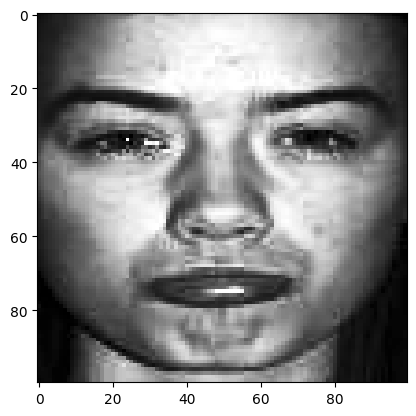

In [85]:
#Imprimo la imagen
plt.imshow(image, cmap='gray')

In [99]:
#imprimimos el label
print(label)

tristeza


<p>Revisemos distribución del label

In [ ]:
#Extraigo en una lista, todos los valores de labels de todos los batches del dataloader
labels = []
train_dl_iter = iter(train_dl)
while True:
    try:
        batch_images, batch_labels = next(train_dl_iter)
        labels.extend(batch_labels.numpy().tolist())
    except:
        break

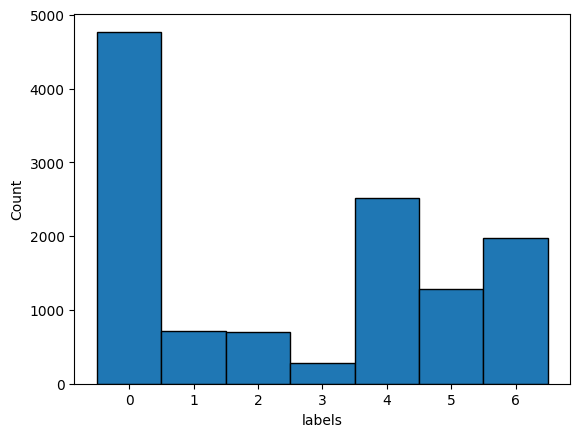

In [116]:
plt.hist(labels,bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5], edgecolor='black')
plt.xlabel('labels')
plt.ylabel('Count')
plt.show()

<p>Vemos que el target no está equitativamente distrubido, siendo la clase 0 la que más muestras posee; mientras que la clase 3, posee significativamente menos

<p>Podemos aplicar un "Weigthed Random Sampler" para asegurar que en cada batch, el modelo reciba una muestra balanceada de clases (<i>Fuente: <link>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</link>)</p>.
<p>De todas formas, para evitar un <i>overfitting</i> de las clases minoritarias, aplicaremos tambien <i>Data Augmentation</i> utilizando transformaciones provistas por Pytorch

In [27]:
from torch.utils.data import WeightedRandomSampler

In [ ]:
#Modificamos las transformaciones anteriores, para aplicar data Augmentation
transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.RandomRotation(10),    #Aplicamos una rotación randomizada de hasta 10 grados  
      transforms.RandomHorizontalFlip(0.5), #Espejamos en eje horizontal con una probabilidad de 0.5  
      transforms.RandomEqualize(p=1.0), #ecualizamos el histograma de las imagenes para lograr mayor constraste y detalle en las mismas (p=1 => se aplica el 100% de las veces)     
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5

#Cargo mi dataset
train_dataset = datasets.ImageFolder(train_data_path,transform=transform)

#obtenemos los pesos de cada clase
class_weights  = []
sample_weights = []
labels = [0,1,2,3,4,5,6]
for label in labels:
    class_weights.append(1/train_dataset.targets.count(label))

#debemos asignar a cada muestra, su "class_weight"
for indx in range(len(train_dataset.targets)):
    #obtengo el label de la muestra correspondiente al índice actual
    label = train_dataset.targets[indx]
    #utilizando la lista "class_weights" guardo el peso correspondiente a la muestra (notar que los pesos se almacenan en orden de label, de 0 a 6)
    sample_weights.append(class_weights[label])

#pasamos a tensor los pesos y definimos el "sampler"
sample_weights = torch.tensor(sample_weights)
sampler = WeightedRandomSampler(weights=sample_weights,num_samples=len(train_dataset.targets))

#Generemos le data_loader
train_dl = DataLoader(train_dataset, batch_size=32, sampler=sampler)

In [43]:
#Extraigo en una lista, todos los valores de labels de todos los batches del dataloader
labels = []
train_dl_iter = iter(train_dl)
while True:
    try:
        batch_images, batch_labels = next(train_dl_iter)
        labels.extend(batch_labels.numpy().tolist())
    except:
        break

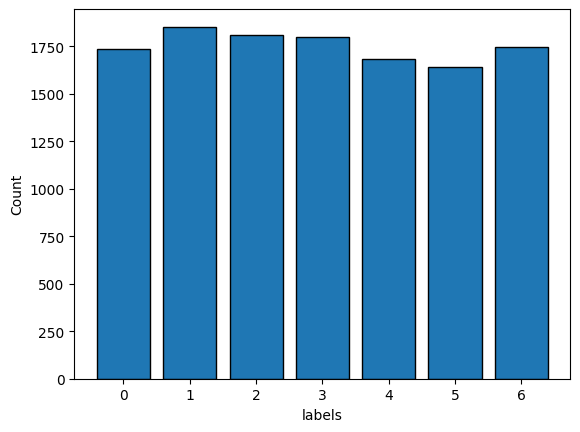

In [46]:
plt.hist(labels,bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5], edgecolor='black',rwidth=0.8)
plt.xlabel('labels')
plt.ylabel('Count')
plt.show()

<p>Observamos ahora que tenemos un balance mucho mayor entre cada clase por época de entrenamiento

<p>Repetimos para el test de validación

In [123]:
#Modificamos las transformaciones anteriores, para aplicar data Augmentation
test_transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5


#Cargo mi dataset
test_dataset = datasets.ImageFolder(test_data_path,transform=test_transform)

#Generemos el data_loader
test_dl = DataLoader(test_dataset, batch_size=32,shuffle=False)

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [122]:
#definimos bloque de convolución
def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2):        
    return torch.nn.Sequential(                               
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # convolución
        torch.nn.ReLU(),                                      # activación
        torch.nn.MaxPool2d(pk)                                # pooling
    )

In [ ]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #                       n_channels:     nro de canales de nuestras imagenes (1 en nuestro caso porque es escala de grises)
    #                       n_outputs:      nro de salidas (7 en nuestro caso; una por cada emoción)
    #                       channels:       Número de canales de cada kernel (o número de subkerles de cada capa)        
    #                       kernel_size:    Tamaño de los kernels
    #                       dropout:        probabilidad de dropout
    #                       padding:        'valid' (kernel no sale de la imagen. Reduce dimension) o 'same' (Kernel puede salir de la imagen. No reduce dimensión)
    #                       stride:         paso que da el kernel sobre la imagen
    #                       pool_kernel:    tamaño del kernel de la capa de pooling
    # 
    #    
    def __init__(self,n_channels, n_outputs, channels, kernel_size, dropout, padding, stride, pool_kernel,fc_input_neurons):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        
        
        #TODO: verifica uso
        self.dropout = nn.Dropout(dropout)
        self.n_channels = n_channels
        self.n_outputs = n_outputs
        self.channels = tuple(channels)
        self.kernel_size = kernel_size
        self.dropout_p = dropout
        self.padding = padding
        self.stride = stride
        self.pool_kernel = pool_kernel
        self.num_conv_blocks = len(self.channels)

        #defino capas de convolución
        self.conv1 = conv_block(c_in=self.n_channels, c_out=self.channels[0], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv1_out = None
        self.conv2 = conv_block(c_in=self.channels[0], c_out=self.channels[1], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv2_out = None
        self.conv3 = conv_block(c_in=self.channels[1], c_out=self.channels[2], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv3_out = None

        #defino la arquitectura del "multi layer perceptron"
        self.fully_connectd = nn.Sequential(
            #Capa de entrada
            #capa fully connected
            nn.Linear(fc_input_neurons, 32),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            #capa de salida
            nn.Linear(32, 7),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X: set de imagenes
    #                    
    #                    
    #                    
    #                    
    #
    def forward(self,X):
        
        self.conv1_out = self.conv1(X)
        self.conv2_out = self.conv2(self.conv1_out)
        self.conv3_out = self.conv3(self.conv2_out)
        #aplicamos un dropout inicial a nuestros datos (ponemos a 0 ciertos datos, entonces el modelo entrena sin ellos y lo forzamos a aprender otros patrones)
        # Es para prevenir overfitting
        y = self.dropout(self.conv3_out)
        y = y.flatten(start_dim=1)
        #Aplicamos nuestra red "fully connected" a los datos
        out = self.fully_connectd(y)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out.squeeze(1)

In [88]:
fc_in_neurons

2304

In [59]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 16, 16)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
#kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
kernel_size=9           # SE MODIFICA VALOR debido a warning de Pytorch "padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created".
                        #   El problema está en que, al utilizar un kernel de dimensión par, no hay un centro definido; Pytorch puede aplicar un padding asimétrico (agregar máx pixels de un lado que en otro)
                        #       pero no está optimizado. Por lo tanto, se modifica para utilizar dimensiones impares de kernel
dropout=0.3             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 3

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[2] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 50

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
cel_loss = nn.CrossEntropyLoss() #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


In [57]:
from sklearn.metrics import accuracy_score, f1_score,classification_report,confusion_matrix
import seaborn as sns

In [62]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = cel_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas

        #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
        classes = torch.argmax(pred, dim=1)
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida CEL obtenida en esta época (como la media de la CEL de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds,average='macro'))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_cel_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = cel_loss(pred,y) 
            batch_cel_test.append(loss.item())

            #Lógica de métricas
            #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
            classes = torch.argmax(pred, dim=1)
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_cel_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds,average='macro'))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train CEL: {cel_train_his[-1]:.4f} | Test CEL: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")



Epoch 0 | Train CEL: 1.3999 | Test CEL: 1.4432 | Test Acc: 0.4866 | Test F1: 0.4164
Epoch 1 | Train CEL: 1.3090 | Test CEL: 1.2818 | Test Acc: 0.5427 | Test F1: 0.4471
Epoch 2 | Train CEL: 1.2156 | Test CEL: 1.2594 | Test Acc: 0.5590 | Test F1: 0.4723
Epoch 3 | Train CEL: 1.1902 | Test CEL: 1.2115 | Test Acc: 0.5652 | Test F1: 0.4726
Epoch 4 | Train CEL: 1.1405 | Test CEL: 1.2774 | Test Acc: 0.5473 | Test F1: 0.4738
Epoch 5 | Train CEL: 1.1230 | Test CEL: 1.1569 | Test Acc: 0.5984 | Test F1: 0.5064
Epoch 6 | Train CEL: 1.0940 | Test CEL: 1.1908 | Test Acc: 0.5799 | Test F1: 0.4952
Epoch 7 | Train CEL: 1.0703 | Test CEL: 1.1242 | Test Acc: 0.5945 | Test F1: 0.5002
Epoch 8 | Train CEL: 1.0459 | Test CEL: 1.2257 | Test Acc: 0.5492 | Test F1: 0.4699
Epoch 9 | Train CEL: 1.0513 | Test CEL: 1.1108 | Test Acc: 0.6072 | Test F1: 0.5070
Epoch 10 | Train CEL: 1.0204 | Test CEL: 1.1874 | Test Acc: 0.5730 | Test F1: 0.4933
Epoch 11 | Train CEL: 1.0151 | Test CEL: 1.2105 | Test Acc: 0.5593 | Test F

KeyboardInterrupt: 

In [67]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 32, 64)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
#kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
kernel_size=9           # SE MODIFICA VALOR debido a warning de Pytorch "padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created".
                        #   El problema está en que, al utilizar un kernel de dimensión par, no hay un centro definido; Pytorch puede aplicar un padding asimétrico (agregar máx pixels de un lado que en otro)
                        #       pero no está optimizado. Por lo tanto, se modifica para utilizar dimensiones impares de kernel
dropout=0.3             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 3

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[2] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 15

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
cel_loss = nn.CrossEntropyLoss() #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [70]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = cel_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas

        #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
        classes = torch.argmax(pred, dim=1)
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida CEL obtenida en esta época (como la media de la CEL de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds,average='macro'))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_cel_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = cel_loss(pred,y) 
            batch_cel_test.append(loss.item())

            #Lógica de métricas
            #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
            classes = torch.argmax(pred, dim=1)
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_cel_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds,average='macro'))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train CEL: {cel_train_his[-1]:.4f} | Test CEL: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")



Epoch 0 | Train CEL: 1.5529 | Test CEL: 1.4765 | Test Acc: 0.4896 | Test F1: 0.3911
Epoch 1 | Train CEL: 1.4040 | Test CEL: 1.2908 | Test Acc: 0.5668 | Test F1: 0.4829
Epoch 2 | Train CEL: 1.3302 | Test CEL: 1.2418 | Test Acc: 0.5851 | Test F1: 0.4673
Epoch 3 | Train CEL: 1.2624 | Test CEL: 1.2016 | Test Acc: 0.5818 | Test F1: 0.4803
Epoch 4 | Train CEL: 1.2168 | Test CEL: 1.1728 | Test Acc: 0.5847 | Test F1: 0.5063
Epoch 5 | Train CEL: 1.1763 | Test CEL: 1.1834 | Test Acc: 0.5812 | Test F1: 0.5102
Epoch 6 | Train CEL: 1.1393 | Test CEL: 1.1611 | Test Acc: 0.6004 | Test F1: 0.5055
Epoch 7 | Train CEL: 1.0882 | Test CEL: 1.1587 | Test Acc: 0.5935 | Test F1: 0.5171
Epoch 8 | Train CEL: 1.0703 | Test CEL: 1.1567 | Test Acc: 0.5916 | Test F1: 0.5113
Epoch 9 | Train CEL: 1.0542 | Test CEL: 1.0864 | Test Acc: 0.6144 | Test F1: 0.5418
Epoch 10 | Train CEL: 1.0227 | Test CEL: 1.0901 | Test Acc: 0.6183 | Test F1: 0.5473
Epoch 11 | Train CEL: 1.0124 | Test CEL: 1.0833 | Test Acc: 0.6294 | Test F

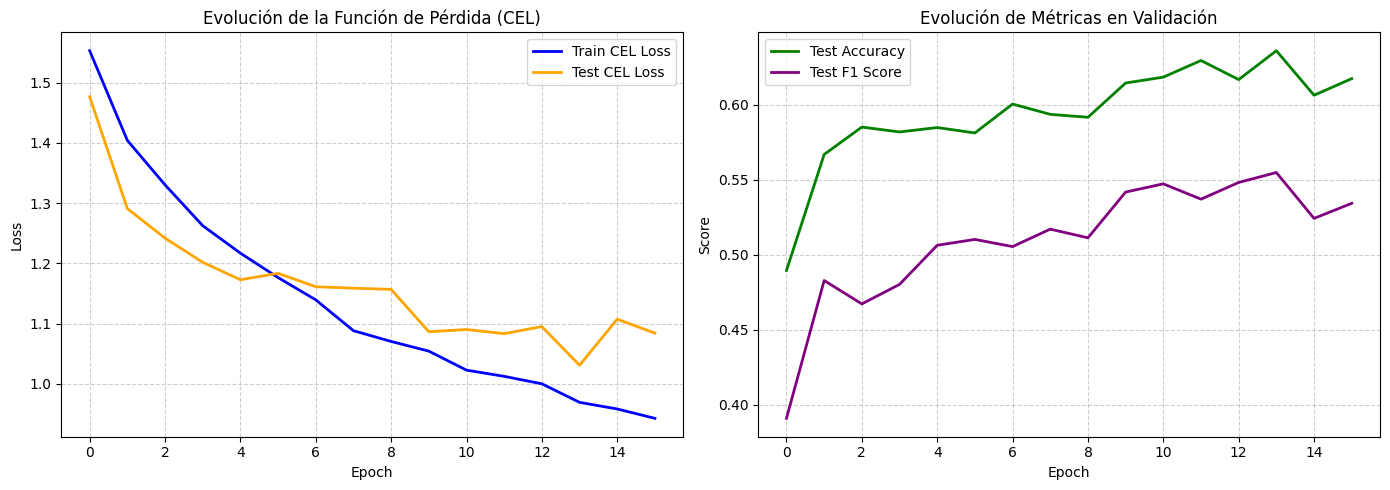

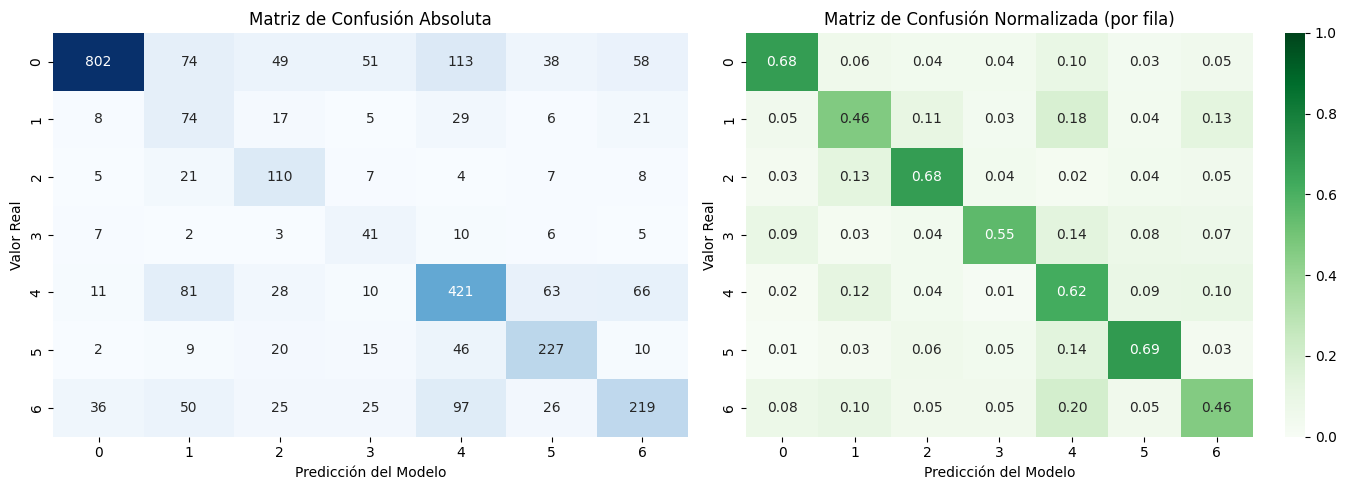

In [71]:
# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (CEL)
ax1.plot(cel_train_his, label='Train CEL Loss', color='blue', linewidth=2)
ax1.plot(cel_test_his, label='Test CEL Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (CEL)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

<p>Observando las curvas de loss vemos que: <ul>
<li><b>Train loss:</b> Con un mayor número de épocas, podría haber continuado disminuyendo</li>
<li><b>Test loss:</b> A partir de la época cinco, empieza a incrementarse y alejarse de la curva de train. Esto podría ser un indicio de overfitting</li>
</ul>

In [81]:
# Generar reporte
report = classification_report(test_targets, test_preds,target_names=['alegria','disgusto','enojo','miedo','seriedad','sorpresa','tristeza'])
print(report)

              precision    recall  f1-score   support

     alegria       0.92      0.68      0.78      1185
    disgusto       0.24      0.46      0.31       160
       enojo       0.44      0.68      0.53       162
       miedo       0.27      0.55      0.36        74
    seriedad       0.58      0.62      0.60       680
    sorpresa       0.61      0.69      0.65       329
    tristeza       0.57      0.46      0.51       478

    accuracy                           0.62      3068
   macro avg       0.52      0.59      0.53      3068
weighted avg       0.68      0.62      0.64      3068



<p>Vemos que tenemos una precisión muy alta en el label "alegria", clase que era predominante en el dataset, por lo cuál, si etiqueta erroneamente como "alegría", es probable que muchas veces, tenga razón. Si vemos el "recall", vemos que en realidad el 68% de los casos que etiquetó como "alegría" eran realmente "alegría", con lo cuál esto refuerza la idea de que el modelo está sufriendo un overfitting y no está aprendiendo correctamente a identificar emociones, tendiendo a etiquetar con la clase mayoritaria. 

Se aumenta el dropout, se achica el kernel y se disminuye su número de canales del kernel:

In [82]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 16, 16)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
#kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
#kernel_size=9           # SE MODIFICA VALOR debido a warning de Pytorch "padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created".
                        #   El problema está en que, al utilizar un kernel de dimensión par, no hay un centro definido; Pytorch puede aplicar un padding asimétrico (agregar máx pixels de un lado que en otro)
                        #       pero no está optimizado. Por lo tanto, se modifica para utilizar dimensiones impares de kernel
kernel_size = 3
dropout=0.5             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 3

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[2] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 15

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
cel_loss = nn.CrossEntropyLoss() #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [83]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = cel_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas

        #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
        classes = torch.argmax(pred, dim=1)
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida CEL obtenida en esta época (como la media de la CEL de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds,average='macro'))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_cel_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = cel_loss(pred,y) 
            batch_cel_test.append(loss.item())

            #Lógica de métricas
            #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
            classes = torch.argmax(pred, dim=1)
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_cel_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds,average='macro'))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train CEL: {cel_train_his[-1]:.4f} | Test CEL: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")



Epoch 0 | Train CEL: 1.8171 | Test CEL: 1.6678 | Test Acc: 0.4612 | Test F1: 0.3625
Epoch 1 | Train CEL: 1.6004 | Test CEL: 1.5534 | Test Acc: 0.4710 | Test F1: 0.3829
Epoch 2 | Train CEL: 1.5222 | Test CEL: 1.4060 | Test Acc: 0.5228 | Test F1: 0.4298
Epoch 3 | Train CEL: 1.4709 | Test CEL: 1.4752 | Test Acc: 0.5143 | Test F1: 0.4367
Epoch 4 | Train CEL: 1.4409 | Test CEL: 1.4401 | Test Acc: 0.5049 | Test F1: 0.4324
Epoch 5 | Train CEL: 1.4243 | Test CEL: 1.4088 | Test Acc: 0.5394 | Test F1: 0.4666
Epoch 6 | Train CEL: 1.3937 | Test CEL: 1.3635 | Test Acc: 0.5551 | Test F1: 0.4764
Epoch 7 | Train CEL: 1.3723 | Test CEL: 1.3327 | Test Acc: 0.5561 | Test F1: 0.4770
Epoch 8 | Train CEL: 1.3596 | Test CEL: 1.3477 | Test Acc: 0.5655 | Test F1: 0.4777
Epoch 9 | Train CEL: 1.3525 | Test CEL: 1.2859 | Test Acc: 0.5740 | Test F1: 0.4855
Epoch 10 | Train CEL: 1.3324 | Test CEL: 1.3028 | Test Acc: 0.5658 | Test F1: 0.4794
Epoch 11 | Train CEL: 1.3018 | Test CEL: 1.2598 | Test Acc: 0.5799 | Test F

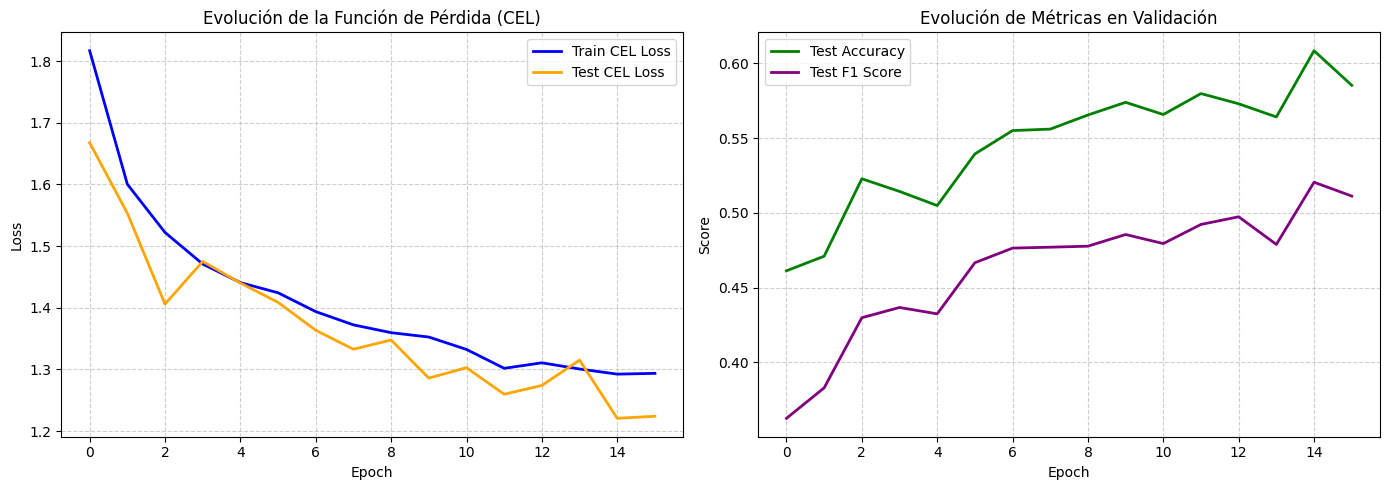

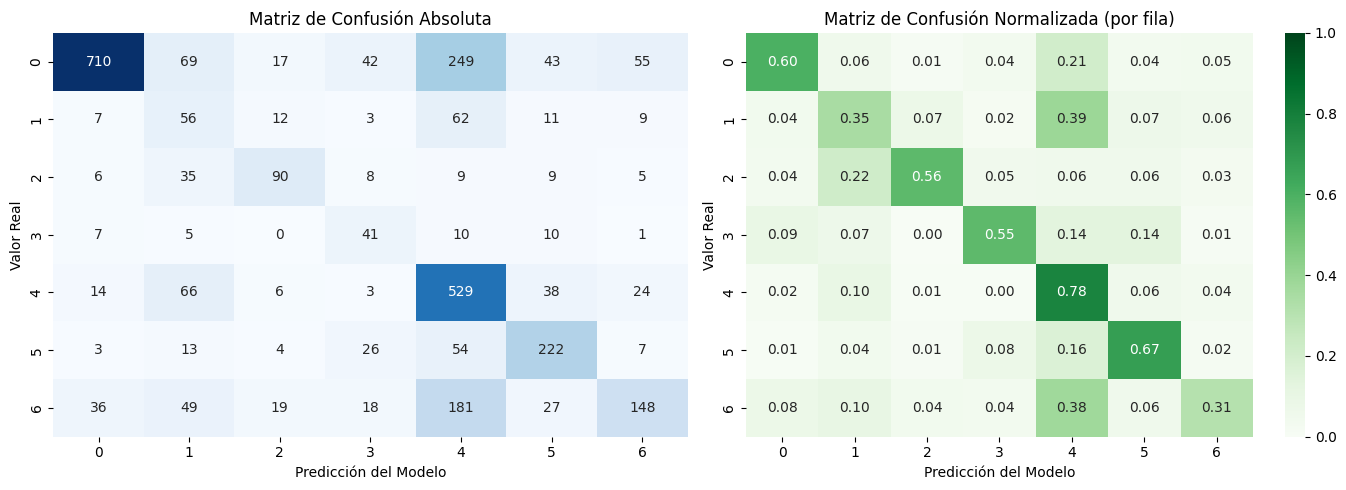

In [84]:
# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (CEL)
ax1.plot(cel_train_his, label='Train CEL Loss', color='blue', linewidth=2)
ax1.plot(cel_test_his, label='Test CEL Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (CEL)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [85]:
# Generar reporte
report = classification_report(test_targets, test_preds,target_names=['alegria','disgusto','enojo','miedo','seriedad','sorpresa','tristeza'])
print(report)

              precision    recall  f1-score   support

     alegria       0.91      0.60      0.72      1185
    disgusto       0.19      0.35      0.25       160
       enojo       0.61      0.56      0.58       162
       miedo       0.29      0.55      0.38        74
    seriedad       0.48      0.78      0.60       680
    sorpresa       0.62      0.67      0.64       329
    tristeza       0.59      0.31      0.41       478

    accuracy                           0.59      3068
   macro avg       0.53      0.55      0.51      3068
weighted avg       0.67      0.59      0.60      3068



<p>De las curvas de pérdida, vemos que mejoramos la situación respecto del overfitting. Aún así, podríamos incrementar la cantidad de épocas, ya que el aún estamos en valores de función de pérdida muy altos.</p> <p>Por otro lado, revisando el "classification report", vemos que se sigue manteniendo una situación muy similar a la anterior: una precicion muy alta para la clase mayoritaria, y valores bajos de f1 para las demás. 


In [91]:
print(f"Tenemos {fc_in_neurons} neuronas de entrada. Por lo tanto, no podemos pasar de este número a 32, debemos agregar otras capas ocultas")

Tenemos 2304 neuronas de entrada. Por lo tanto, no podemos pasar de este número a 32, debemos agregar otras capas ocultas


In [111]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #                       n_channels:     nro de canales de nuestras imagenes (1 en nuestro caso porque es escala de grises)
    #                       n_outputs:      nro de salidas (7 en nuestro caso; una por cada emoción)
    #                       channels:       Número de canales de cada kernel (o número de subkerles de cada capa)        
    #                       kernel_size:    Tamaño de los kernels
    #                       dropout:        probabilidad de dropout
    #                       padding:        'valid' (kernel no sale de la imagen. Reduce dimension) o 'same' (Kernel puede salir de la imagen. No reduce dimensión)
    #                       stride:         paso que da el kernel sobre la imagen
    #                       pool_kernel:    tamaño del kernel de la capa de pooling
    # 
    #    
    def __init__(self,n_channels, n_outputs, channels, kernel_size, dropout, padding, stride, pool_kernel,fc_input_neurons):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        
        
        #TODO: verifica uso
        self.dropout = nn.Dropout(dropout)
        self.n_channels = n_channels
        self.n_outputs = n_outputs
        self.channels = tuple(channels)
        self.kernel_size = kernel_size
        self.dropout_p = dropout
        self.padding = padding
        self.stride = stride
        self.pool_kernel = pool_kernel
        self.num_conv_blocks = len(self.channels)

        #defino capas de convolución
        self.conv1 = conv_block(c_in=self.n_channels, c_out=self.channels[0], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv1_out = None
        self.conv2 = conv_block(c_in=self.channels[0], c_out=self.channels[1], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv2_out = None
        self.conv3 = conv_block(c_in=self.channels[1], c_out=self.channels[2], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv3_out = None

        #defino la arquitectura del "multi layer perceptron"
        self.fully_connectd = nn.Sequential(
            #Capa de entrada
            #capa fully connected
            nn.Linear(fc_input_neurons, 512),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
                   
            #capa de salida
            nn.Linear(512, 7),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X: set de imagenes
    #                    
    #                    
    #                    
    #                    
    #
    def forward(self,X):
        
        self.conv1_out = self.conv1(X)
        self.conv2_out = self.conv2(self.conv1_out)
        self.conv3_out = self.conv3(self.conv2_out)

        #aplicamos un dropout inicial a nuestros datos (ponemos a 0 ciertos datos, entonces el modelo entrena sin ellos y lo forzamos a aprender otros patrones)
        # Es para prevenir overfitting
        y = self.dropout(self.conv3_out)
        y = y.flatten(start_dim=1)
        #Aplicamos nuestra red "fully connected" a los datos
        out = self.fully_connectd(y)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out

In [113]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 32, 64)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
#kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
#kernel_size=9           # SE MODIFICA VALOR debido a warning de Pytorch "padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created".
                        #   El problema está en que, al utilizar un kernel de dimensión par, no hay un centro definido; Pytorch puede aplicar un padding asimétrico (agregar máx pixels de un lado que en otro)
                        #       pero no está optimizado. Por lo tanto, se modifica para utilizar dimensiones impares de kernel
kernel_size = 3
dropout=0.5             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 3

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[2] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 20

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
cel_loss = nn.CrossEntropyLoss() #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [114]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = cel_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas

        #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
        classes = torch.argmax(pred, dim=1)
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida CEL obtenida en esta época (como la media de la CEL de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds,average='macro'))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_cel_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = cel_loss(pred,y) 
            batch_cel_test.append(loss.item())

            #Lógica de métricas
            #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
            classes = torch.argmax(pred, dim=1)
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_cel_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds,average='macro'))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train CEL: {cel_train_his[-1]:.4f} | Test CEL: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")



Epoch 0 | Train CEL: 1.6000 | Test CEL: 1.4470 | Test Acc: 0.5183 | Test F1: 0.4373
Epoch 1 | Train CEL: 1.3037 | Test CEL: 1.3340 | Test Acc: 0.5414 | Test F1: 0.4662
Epoch 2 | Train CEL: 1.1614 | Test CEL: 1.1363 | Test Acc: 0.6037 | Test F1: 0.5230
Epoch 3 | Train CEL: 1.0928 | Test CEL: 1.1024 | Test Acc: 0.5952 | Test F1: 0.5356
Epoch 4 | Train CEL: 1.0210 | Test CEL: 1.1792 | Test Acc: 0.5711 | Test F1: 0.4942
Epoch 5 | Train CEL: 0.9660 | Test CEL: 1.1194 | Test Acc: 0.5919 | Test F1: 0.5269
Epoch 6 | Train CEL: 0.9165 | Test CEL: 1.0422 | Test Acc: 0.6239 | Test F1: 0.5420
Epoch 7 | Train CEL: 0.8842 | Test CEL: 1.1233 | Test Acc: 0.5903 | Test F1: 0.5290
Epoch 8 | Train CEL: 0.8439 | Test CEL: 1.0829 | Test Acc: 0.6125 | Test F1: 0.5377
Epoch 9 | Train CEL: 0.8344 | Test CEL: 1.0249 | Test Acc: 0.6226 | Test F1: 0.5714
Epoch 10 | Train CEL: 0.7893 | Test CEL: 1.1659 | Test Acc: 0.5720 | Test F1: 0.5370


KeyboardInterrupt: 

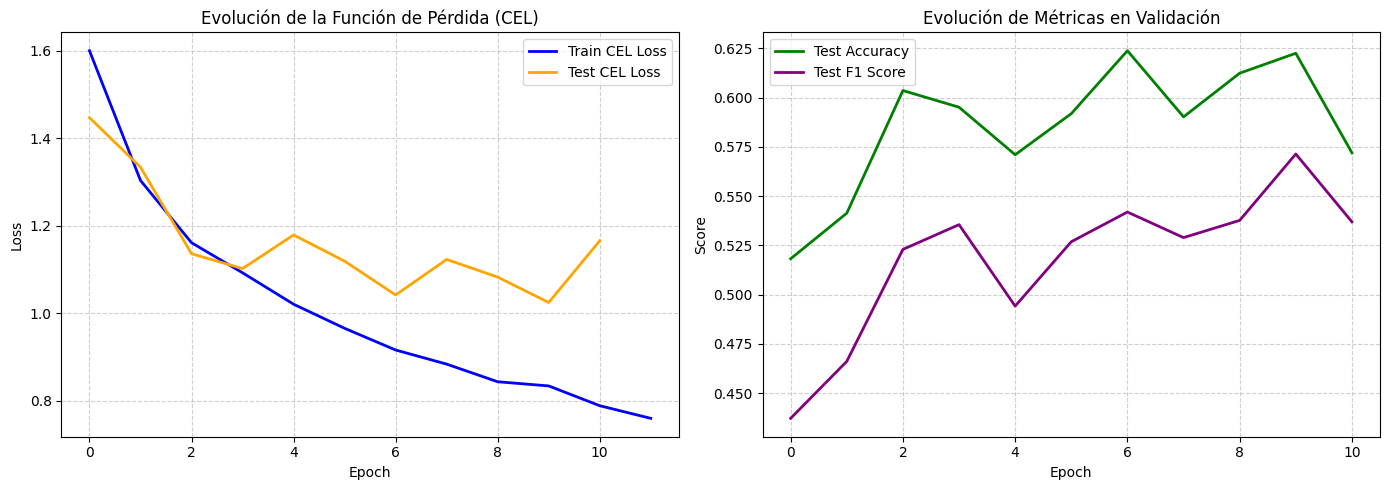

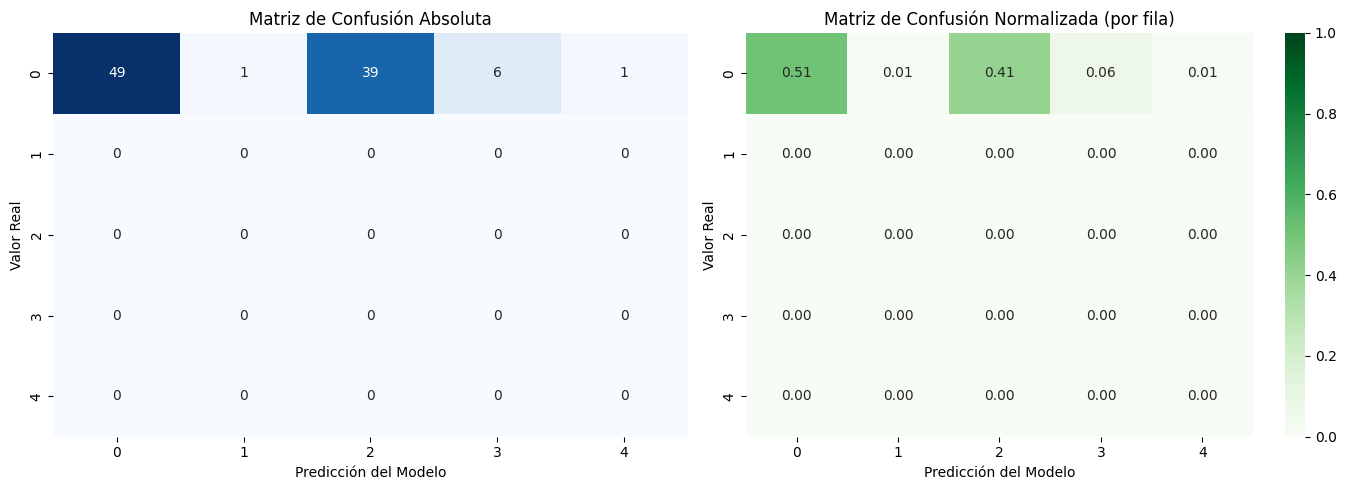

In [115]:
# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (CEL)
ax1.plot(cel_train_his, label='Train CEL Loss', color='blue', linewidth=2)
ax1.plot(cel_test_his, label='Test CEL Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (CEL)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [110]:
# Generar reporte
report = classification_report(test_targets, test_preds,target_names=['alegria','disgusto','enojo','miedo','seriedad','sorpresa','tristeza'])
print(report)

              precision    recall  f1-score   support

     alegria       0.93      0.57      0.71      1185
    disgusto       0.33      0.32      0.33       160
       enojo       0.66      0.56      0.61       162
       miedo       0.52      0.43      0.47        74
    seriedad       0.43      0.90      0.58       680
    sorpresa       0.61      0.72      0.66       329
    tristeza       0.74      0.29      0.42       478

    accuracy                           0.60      3068
   macro avg       0.60      0.54      0.54      3068
weighted avg       0.70      0.60      0.60      3068



<p>Se realiza prueba utilizando los weights the CrossEntropyLoss en lugar de utilizar el Weigthed sampler 

In [139]:
transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.RandomRotation(10),  
      transforms.RandomHorizontalFlip(0.5),
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5

#Cargo mi dataset
train_dataset = datasets.ImageFolder(train_data_path,transform=transform)

#Definimos el DataLoader
train_dl = DataLoader(train_dataset,
                                         batch_size=64,
                                         shuffle=True)


#obtenemos los pesos de cada clase, para pasarlos a "CrossEntropyLoss" y que penalize en mayor medida errores al clasificar las clases minoritarias
class_weights  = []
labels = [0,1,2,3,4,5,6]
for label in labels:
    class_weights.append(1/train_dataset.targets.count(label))

class_weights = torch.tensor(class_weights).to(device)

In [140]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #                       n_channels:     nro de canales de nuestras imagenes (1 en nuestro caso porque es escala de grises)
    #                       n_outputs:      nro de salidas (7 en nuestro caso; una por cada emoción)
    #                       channels:       Número de canales de cada kernel (o número de subkerles de cada capa)        
    #                       kernel_size:    Tamaño de los kernels
    #                       dropout:        probabilidad de dropout
    #                       padding:        'valid' (kernel no sale de la imagen. Reduce dimension) o 'same' (Kernel puede salir de la imagen. No reduce dimensión)
    #                       stride:         paso que da el kernel sobre la imagen
    #                       pool_kernel:    tamaño del kernel de la capa de pooling
    # 
    #    
    def __init__(self,n_channels, n_outputs, channels, kernel_size, dropout, padding, stride, pool_kernel,fc_input_neurons):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        
        
        #TODO: verifica uso
        self.dropout = nn.Dropout(dropout)
        self.n_channels = n_channels
        self.n_outputs = n_outputs
        self.channels = tuple(channels)
        self.kernel_size = kernel_size
        self.dropout_p = dropout
        self.padding = padding
        self.stride = stride
        self.pool_kernel = pool_kernel
        self.num_conv_blocks = len(self.channels)

        #defino capas de convolución
        self.conv1 = conv_block(c_in=self.n_channels, c_out=self.channels[0], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv1_out = None
        self.conv2 = conv_block(c_in=self.channels[0], c_out=self.channels[1], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv2_out = None
        self.conv3 = conv_block(c_in=self.channels[1], c_out=self.channels[2], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv3_out = None
        self.conv4 = conv_block(c_in=self.channels[2], c_out=self.channels[3], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv4_out = None
        #defino la arquitectura del "multi layer perceptron"
        self.fully_connectd = nn.Sequential(
            #Capa de entrada
            #capa fully connected
            nn.Linear(fc_input_neurons, 512),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
                   
            #capa de salida
            nn.Linear(512, 7),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X: set de imagenes
    #                    
    #                    
    #                    
    #                    
    #
    def forward(self,X):
        
        self.conv1_out = self.conv1(X)
        self.conv2_out = self.conv2(self.conv1_out)
        self.conv3_out = self.conv3(self.conv2_out)
        self.conv4_out = self.conv4(self.conv3_out)
        #aplicamos un dropout inicial a nuestros datos (ponemos a 0 ciertos datos, entonces el modelo entrena sin ellos y lo forzamos a aprender otros patrones)
        # Es para prevenir overfitting
        y = self.dropout(self.conv4_out)
        y = y.flatten(start_dim=1)
        #Aplicamos nuestra red "fully connected" a los datos
        out = self.fully_connectd(y)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out

In [141]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 32, 64, 128)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
#kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
#kernel_size=9           # SE MODIFICA VALOR debido a warning de Pytorch "padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created".
                        #   El problema está en que, al utilizar un kernel de dimensión par, no hay un centro definido; Pytorch puede aplicar un padding asimétrico (agregar máx pixels de un lado que en otro)
                        #       pero no está optimizado. Por lo tanto, se modifica para utilizar dimensiones impares de kernel
kernel_size = 3
dropout=0.5             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 4

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[3] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 20

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
cel_loss = nn.CrossEntropyLoss(weight=class_weights) #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)




In [142]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for x,y in train_dl:
        #pasamos todo a GPU si está disponible
        x = x.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(x)

        #computamos el valor de la función de pérdida
        loss = cel_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas

        #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
        classes = torch.argmax(pred, dim=1)
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida CEL obtenida en esta época (como la media de la CEL de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds,average='macro'))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_cel_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for x,y in test_dl:
            #pasamos todo a GPU si está disponible
            x = x.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(x)

            #computamos el valor de la función de pérdida
            loss = cel_loss(pred,y) 
            batch_cel_test.append(loss.item())

            #Lógica de métricas
            #Obtenemos la clase con la mayor puntuación (argmax) en la dimensión 1 (clases)
            classes = torch.argmax(pred, dim=1)
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_cel_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds,average='macro'))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train CEL: {cel_train_his[-1]:.4f} | Test CEL: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")



Epoch 0 | Train CEL: 1.8847 | Test CEL: 1.7088 | Test Acc: 0.3977 | Test F1: 0.2879
Epoch 1 | Train CEL: 1.6593 | Test CEL: 1.4502 | Test Acc: 0.4423 | Test F1: 0.3772
Epoch 2 | Train CEL: 1.5014 | Test CEL: 1.1885 | Test Acc: 0.5746 | Test F1: 0.4674
Epoch 3 | Train CEL: 1.3864 | Test CEL: 1.1482 | Test Acc: 0.6043 | Test F1: 0.4754
Epoch 4 | Train CEL: 1.3153 | Test CEL: 1.2004 | Test Acc: 0.5717 | Test F1: 0.4509
Epoch 5 | Train CEL: 1.2804 | Test CEL: 1.0079 | Test Acc: 0.6428 | Test F1: 0.5417
Epoch 6 | Train CEL: 1.2284 | Test CEL: 1.0088 | Test Acc: 0.6379 | Test F1: 0.5348
Epoch 7 | Train CEL: 1.1917 | Test CEL: 1.0390 | Test Acc: 0.6382 | Test F1: 0.5329
Epoch 8 | Train CEL: 1.1601 | Test CEL: 1.0678 | Test Acc: 0.6072 | Test F1: 0.5181
Epoch 9 | Train CEL: 1.1310 | Test CEL: 0.9375 | Test Acc: 0.6718 | Test F1: 0.5746
Epoch 10 | Train CEL: 1.1122 | Test CEL: 1.0217 | Test Acc: 0.6268 | Test F1: 0.5475
Epoch 11 | Train CEL: 1.0879 | Test CEL: 0.9182 | Test Acc: 0.6737 | Test F

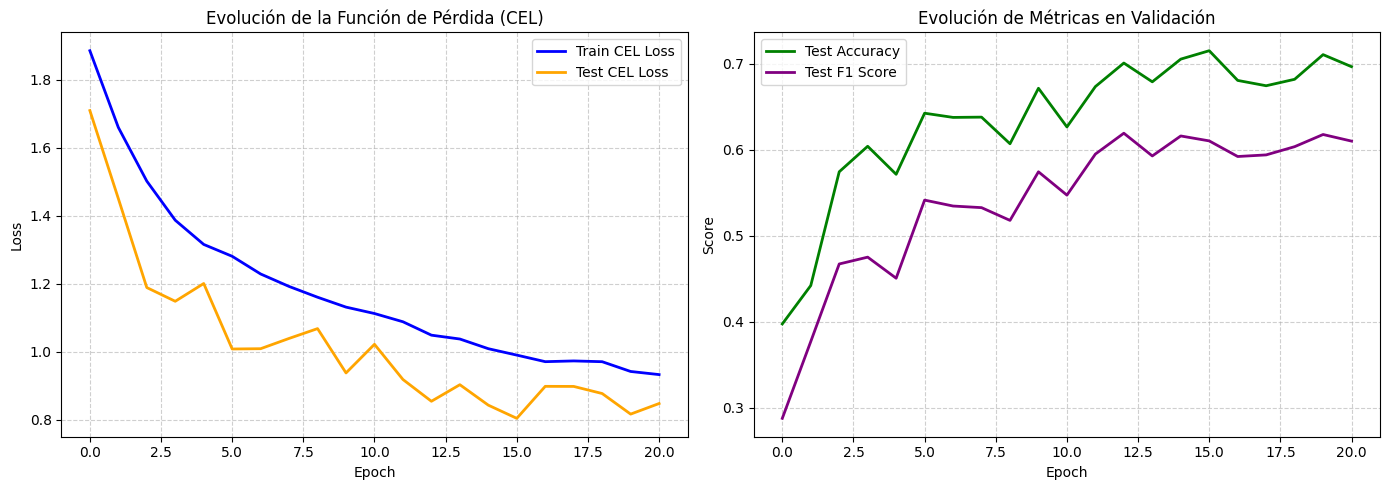

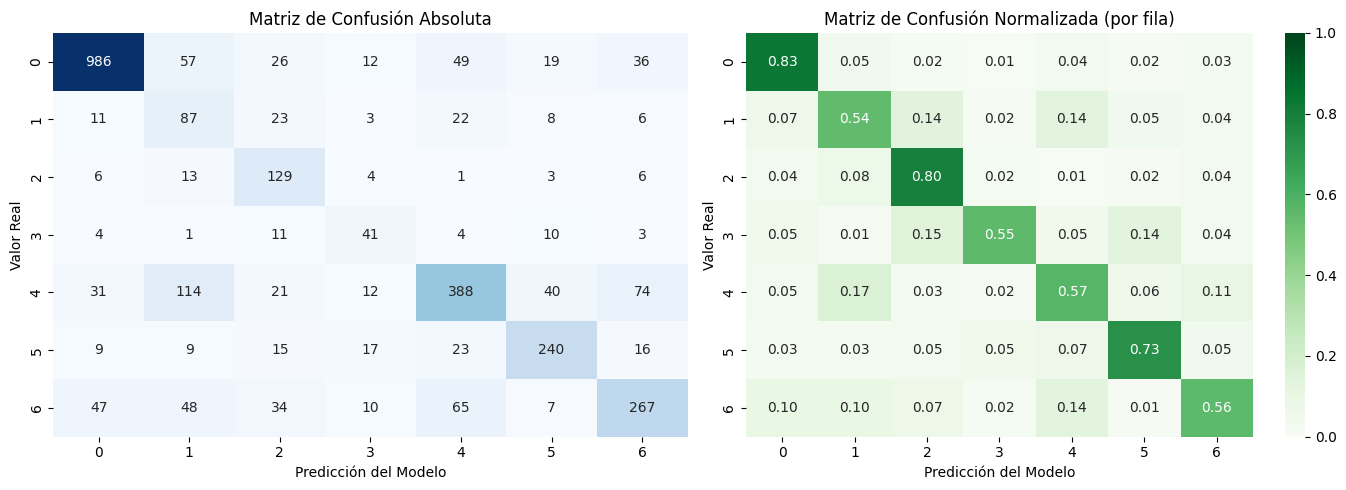

In [143]:
# Grafico curvas de función de pérdida de train y test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss (CEL)
ax1.plot(cel_train_his, label='Train CEL Loss', color='blue', linewidth=2)
ax1.plot(cel_test_his, label='Test CEL Loss', color='orange', linewidth=2)
ax1.set_title('Evolución de la Función de Pérdida (CEL)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico Accuracy y F1 Score
ax2.plot(acc_test_his, label='Test Accuracy', color='green', linewidth=2)
ax2.plot(f1_test_his, label='Test F1 Score', color='purple', linewidth=2)
ax2.set_title('Evolución de Métricas en Validación')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Genero las matrices de confusión
cm_absolute = confusion_matrix(test_targets, test_preds)
cm_normalized = confusion_matrix(test_targets, test_preds, normalize='true')

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_absolute, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Matriz de Confusión Absoluta')
ax3.set_xlabel('Predicción del Modelo')
ax3.set_ylabel('Valor Real')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax4, vmin=0, vmax=1)
ax4.set_title('Matriz de Confusión Normalizada (por fila)')
ax4.set_xlabel('Predicción del Modelo')
ax4.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

In [144]:
# Generar reporte
report = classification_report(test_targets, test_preds,target_names=['alegria','disgusto','enojo','miedo','seriedad','sorpresa','tristeza'])
print(report)

              precision    recall  f1-score   support

     alegria       0.90      0.83      0.87      1185
    disgusto       0.26      0.54      0.36       160
       enojo       0.50      0.80      0.61       162
       miedo       0.41      0.55      0.47        74
    seriedad       0.70      0.57      0.63       680
    sorpresa       0.73      0.73      0.73       329
    tristeza       0.65      0.56      0.60       478

    accuracy                           0.70      3068
   macro avg       0.60      0.65      0.61      3068
weighted avg       0.73      0.70      0.71      3068



<p>Para esta arquitectura observamos una mejora en las métricas<ul>
<li>Evaluando la evolución de las funciones de pérdida tanto en train como en test, podemos ver que el modelo ya no sufre de overfitting</li>
<li>Vemos que han mejorado los f1 score de todas las categorias</li>
</ul>

<P>Procedemos a guardar el modelo</P>

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
